In [ ]:
#important libraries
import torch
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader, random_split
import random
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)

# 10 colors are defined for digits 0 to 9
COLORS = torch.tensor([
    [255, 0, 0],
    [0, 255, 0],
    [0, 0, 255],
    [255, 255, 0],
    [0, 255, 255],
    [255, 0, 255],
    [255, 128, 0],
    [128, 0, 128],
    [0, 255, 128],
    [255, 192, 203]
], dtype=torch.float32)

# A Dataset is created where 95% sample will have correct color-label pairing and rest 5% are assigned a random incorrect color
# Incorrect means if 0 was assigned red then in other 5%, anything other than red was chosen.
# Each grayscale MNIST digit is converted into a colored RGB images.
# Background pixels aare replaced with random noise and final output is a 3 channel RGB tensor.

class ColoredMNIST(Dataset):
    def __init__(self, train=True, bias_ratio=0.95):
        self.mnist = datasets.MNIST(root="./data",train=train,download=True)
        self.train = train
        self.bias_ratio = bias_ratio
        self.color_assignments = self._assign_colors()

    def _assign_colors(self):
        targets = self.mnist.targets
        assignments = []

        for label in targets:
            label = label.item()
            if self.train and random.random() < self.bias_ratio:
                assignments.append(label)
            else:
                # incorrect colors are picked here
                choices = list(range(10))
                choices.remove(label)
                assignments.append(random.choice(choices))

        return assignments

    def _colorize(self, img, color_idx):
        img = img.float() / 255.0  # normalization
        color = COLORS[color_idx] / 255.0  # color normalization

        rgb = img.unsqueeze(-1) * color  # (28,28,3)

        noise = torch.randint(0, 60, (28, 28, 3)).float() / 255.0

        background_mask = (img < 0.08).unsqueeze(-1)

        final_img = torch.where(background_mask, noise, rgb)

        return final_img.permute(2, 0, 1)  # (C,H,W)

    def __getitem__(self, idx):
        img = self.mnist.data[idx]
        label = self.mnist.targets[idx].item()
        color_idx = self.color_assignments[idx]
        return self._colorize(img, color_idx), label

    def __len__(self):
        return len(self.mnist)


train_dataset = ColoredMNIST(train=True, bias_ratio=0.95)
test_dataset = ColoredMNIST(train=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 515kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.81MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.91MB/s]


In [ ]:
# Verification of the color-label relation. It means that whehther approx 95% of the samples have been corrected assigned or not.
def compute_bias_statistics(dataset):
    counts = {digit: 0 for digit in range(10)}
    dominant_counts = {digit: 0 for digit in range(10)}

    for idx in range(len(dataset)):
        label = dataset.mnist.targets[idx].item()
        color = dataset.color_assignments[idx]

        counts[label] += 1
        if color == label:
            dominant_counts[label] += 1

    print("Digit | Dominant Color %")
    print("-----------------------")

    for digit in range(10):
        ratio = dominant_counts[digit] / counts[digit]
        print(f"{digit:>5} | {ratio:.4f}")


compute_bias_statistics(train_dataset)


Digit | Dominant Color %
-----------------------
    0 | 0.9480
    1 | 0.9506
    2 | 0.9554
    3 | 0.9517
    4 | 0.9451
    5 | 0.9478
    6 | 0.9534
    7 | 0.9512
    8 | 0.9511
    9 | 0.9509


In [ ]:
# Function to visualise the dataset
def visualize_digits(dataset, title):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title)

    shown = set()

    for idx in range(len(dataset)):
        img, label = dataset[idx]
        if label in shown:
            continue

        row, col = divmod(label, 5)
        img_np = img.permute(1, 2, 0).numpy()

        axes[row, col].imshow(img_np)
        axes[row, col].set_title(f"Digit:{label} | Color:{dataset.color_assignments[idx]}")
        axes[row, col].axis("off")

        shown.add(label)

        if len(shown) == 10:
            break

    plt.tight_layout()
    plt.show()

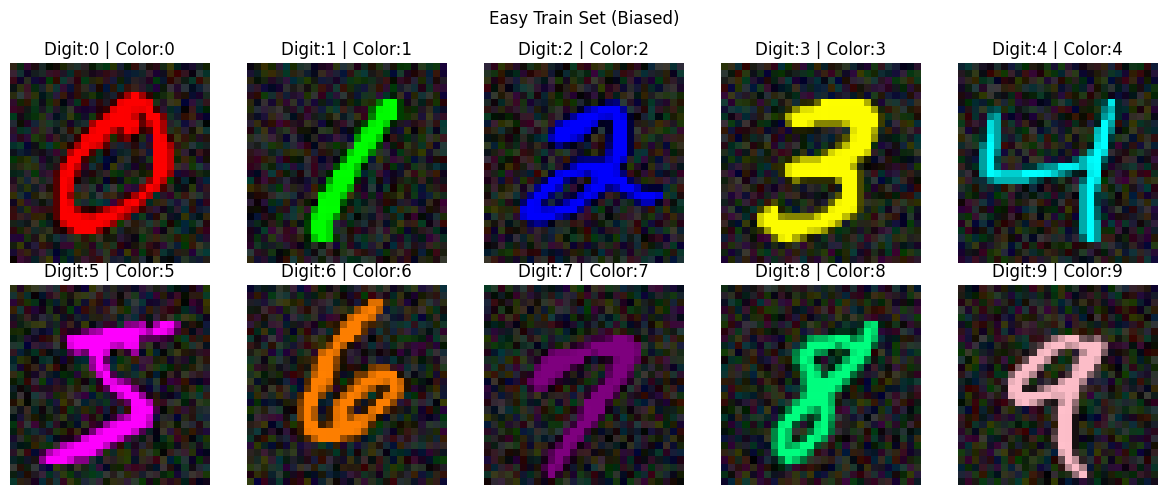

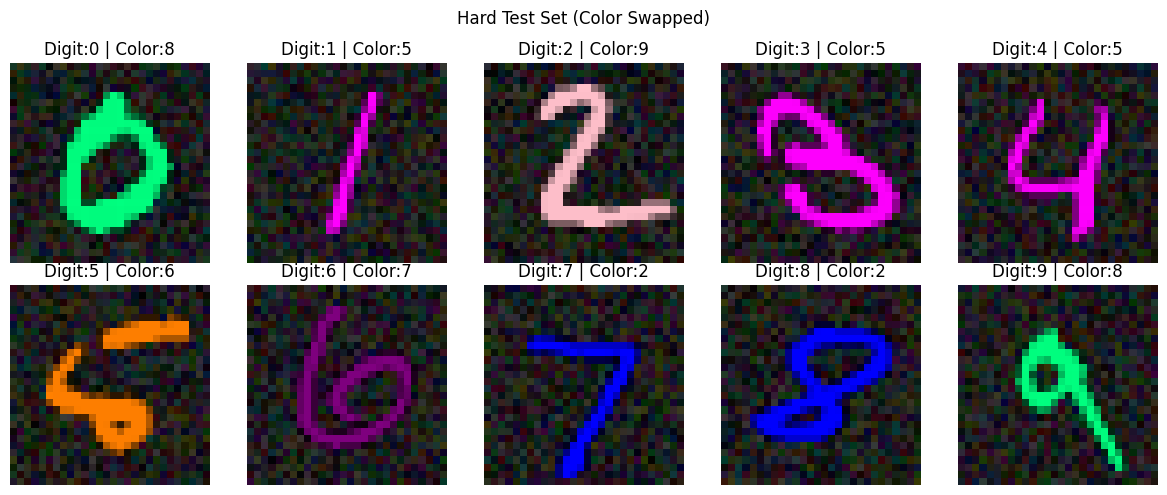

In [ ]:
# Visualize training set
visualize_digits(train_dataset, "Easy Train Set (Biased)")

# Visualize test set (will violate correlation)
visualize_digits(test_dataset, "Hard Test Set (Color Swapped)")

# **Task 6 (Version 1)**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Dataset is being loaded for training purpose. Training for 85% and Validation is 15%.
# Split train into train/val
train_size = int(0.85 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_set, val_set = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
#Simple CNN was used for driving the experiments.
#Simple CNN was used because all the learned behaviours that it picked up was solely due to training on the modified MNIST.
#ResNet-18 has been trained on ImageNet and contain rich shape and texture and hence it was left out.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    train_acc = evaluate(train_loader)
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

hard_test_acc = evaluate(test_loader)
print(f"Hard Test Accuracy = {hard_test_acc:.4f}")

Epoch 1: Train Acc = 0.9496, Val Acc = 0.9524
Epoch 2: Train Acc = 0.9508, Val Acc = 0.9536
Epoch 3: Train Acc = 0.9514, Val Acc = 0.9537
Epoch 4: Train Acc = 0.9514, Val Acc = 0.9539
Epoch 5: Train Acc = 0.9582, Val Acc = 0.9611
Hard Test Accuracy = 0.1835


In [ ]:
torch.save(model.state_dict(), "model_5epoch.pth")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 5-epoch model
model = SimpleCNN().to(device)
model.load_state_dict(torch.load("model_5epoch.pth", map_location=device))
model.eval()

# Weights Frozen
for param in model.parameters():
    param.requires_grad = False

In [ ]:
activations = []

def hook_fn(module, input, output):
    activations.append(output.detach().cpu())

# Register hook (last conv layer)
handle = model.features[6].register_forward_hook(hook_fn)

print("Hook registered.")

Hook registered.


In [ ]:
from torch.utils.data import DataLoader, Subset

# First 5000 training samples are taken.
subset_indices = list(range(5000))
train_subset = Subset(train_dataset, subset_indices)

loader = DataLoader(train_subset, batch_size=128, shuffle=False)

model.eval()

for x, _ in loader:
    x = x.to(device)
    _ = model(x)

print("Forward pass complete.")

Forward pass complete.


In [ ]:
# All batches are combined
# 'activations' is a list where each element contains feature maps from one batch
all_acts = torch.cat(activations, dim=0)

print("Activation shape:", all_acts.shape)

Activation shape: torch.Size([5000, 128, 7, 7])


In [ ]:
N = all_acts.size(0)
flat_acts = all_acts.view(N, -1)

print("Flattened shape:", flat_acts.shape)

Flattened shape: torch.Size([5000, 6272])


In [ ]:
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)  # Encoder compresses input representation into sparse hidden features
        self.decoder = nn.Linear(hidden_dim, input_dim) # Decoder reconstructs the original representation from hidden features

    def forward(self, x):
        hidden = torch.relu(self.encoder(x))
        recon = self.decoder(hidden)
        return recon, hidden

In [ ]:
input_dim = flat_acts.size(1) # Input dimension equals flattened activation size ( 6272)
hidden_dim = input_dim * 2 # Hidden dimension are made twice the size

sae = SparseAutoencoder(input_dim, hidden_dim).to(device) #SAE initialised

optimizer = torch.optim.Adam(sae.parameters(), lr=1e-3)

In [ ]:
lambda_l1 = 1e-5  # sparsity strength
epochs = 10

dataset_tensor = flat_acts.to(device)

for epoch in range(epochs):
    sae.train()

    recon, hidden = sae(dataset_tensor)

    recon_loss = torch.mean((recon - dataset_tensor) ** 2) # It measures how well SAE reconstructs original activations
    l1_loss = torch.mean(torch.abs(hidden)) #L1 sparsity loss encourages most hidden neurons to remain inactive

    loss = recon_loss + lambda_l1 * l1_loss # Total SAE loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} | Recon Loss: {recon_loss.item():.6f} | L1: {l1_loss.item():.6f}")

Epoch 1 | Recon Loss: 35.549534 | L1: 1.233596
Epoch 2 | Recon Loss: 2894.459229 | L1: 4.869972
Epoch 3 | Recon Loss: 33.661850 | L1: 1.243949
Epoch 4 | Recon Loss: 35.613403 | L1: 0.150067
Epoch 5 | Recon Loss: 33.913033 | L1: 0.045504
Epoch 6 | Recon Loss: 33.844147 | L1: 0.040371
Epoch 7 | Recon Loss: 30.711071 | L1: 0.042072
Epoch 8 | Recon Loss: 26.321472 | L1: 0.058080
Epoch 9 | Recon Loss: 21.583902 | L1: 0.087450
Epoch 10 | Recon Loss: 18.120459 | L1: 0.120165


In [ ]:
sae.eval()

with torch.no_grad():
    _, hidden = sae(dataset_tensor)

hidden = hidden.cpu()
print("Hidden shape:", hidden.shape)

Hidden shape: torch.Size([5000, 12544])


In [ ]:
neuron_variance = hidden.var(dim=0)

# Top 10 neurons are selected
top_neurons = torch.topk(neuron_variance, k=10).indices

print("Top neurons:", top_neurons)

Top neurons: tensor([ 6119,  2594,  5427,  1546,  3874,  3744, 10434,  5289,  9474,  4651])


In [ ]:
import matplotlib.pyplot as plt

def visualize_top_activations(neuron_idx, top_k=5):
    activations = hidden[:, neuron_idx]
    top_indices = torch.topk(activations, k=top_k).indices

    plt.figure(figsize=(12,3))

    for i, idx in enumerate(top_indices):
        img, label = train_subset[idx]
        img_np = img.permute(1,2,0).numpy()

        plt.subplot(1, top_k, i+1)
        plt.imshow(img_np)
        plt.title(f"Label: {label}")
        plt.axis("off")

    plt.suptitle(f"Neuron {neuron_idx} - Top Activations")
    plt.show()

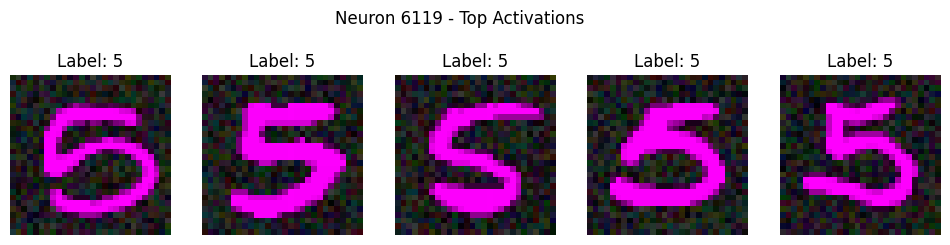

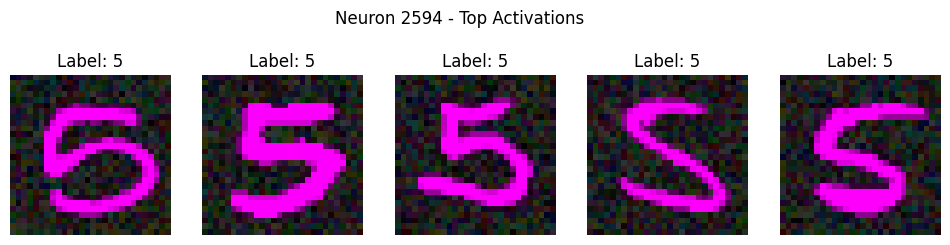

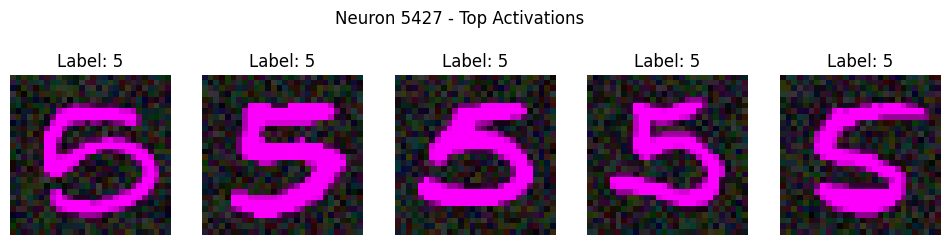

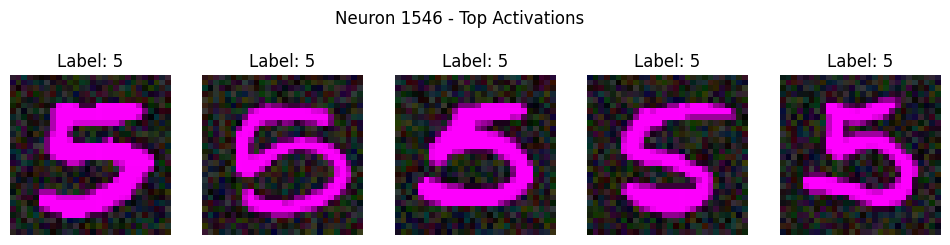

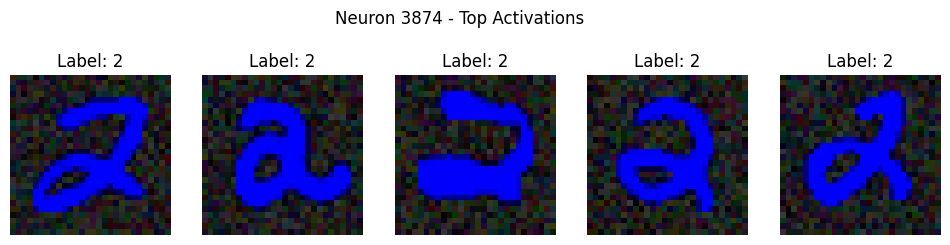

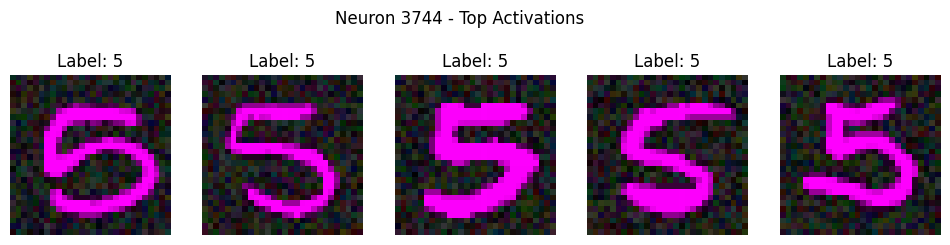

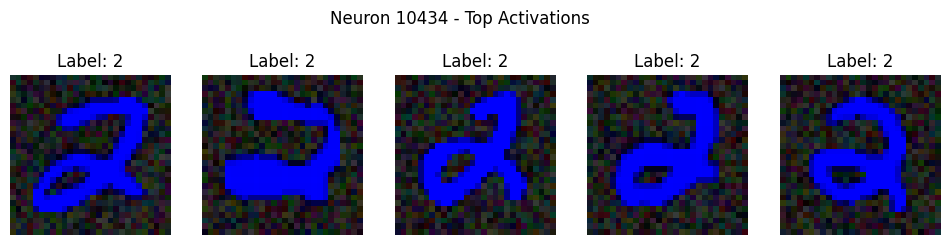

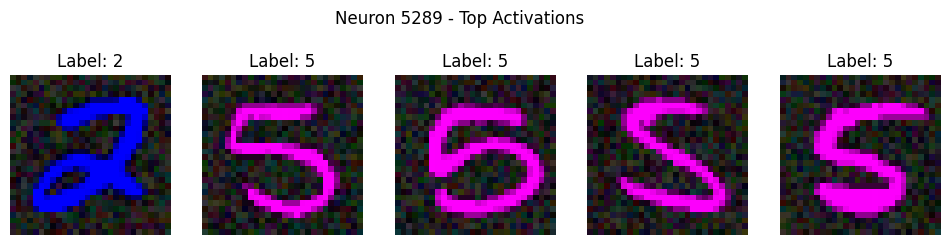

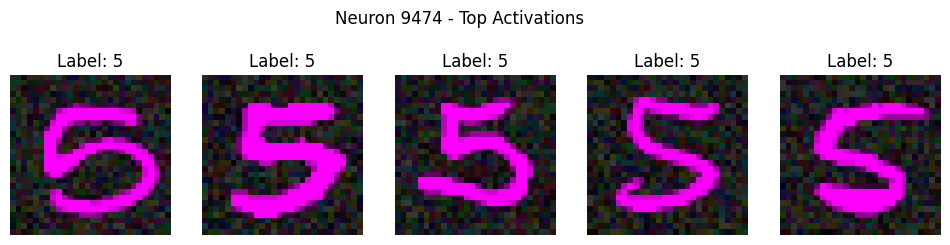

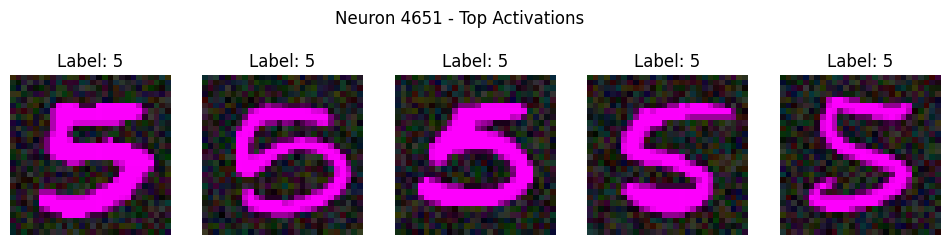

In [ ]:
for neuron in top_neurons[:10]:
    visualize_top_activations(neuron.item())

# **Task 6 (Version 2)**

In [ ]:
#Simple CNN was used for driving the experiments.
#Simple CNN was used because all the learned behaviours that it picked up was solely due to training on the modified MNIST.
#ResNet-18 has been trained on ImageNet and contain rich shape and texture and hence it was left out.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    train_acc = evaluate(train_loader)
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

hard_test_acc = evaluate(test_loader)
print(f"Hard Test Accuracy = {hard_test_acc:.4f}")

Epoch 1: Train Acc = 0.9467, Val Acc = 0.9487
Epoch 2: Train Acc = 0.9510, Val Acc = 0.9534
Epoch 3: Train Acc = 0.9519, Val Acc = 0.9538
Epoch 4: Train Acc = 0.9571, Val Acc = 0.9593
Epoch 5: Train Acc = 0.9629, Val Acc = 0.9643
Epoch 6: Train Acc = 0.9709, Val Acc = 0.9730
Epoch 7: Train Acc = 0.9749, Val Acc = 0.9749
Epoch 8: Train Acc = 0.9792, Val Acc = 0.9813
Epoch 9: Train Acc = 0.9833, Val Acc = 0.9843
Epoch 10: Train Acc = 0.9810, Val Acc = 0.9813
Hard Test Accuracy = 0.6728


In [ ]:
torch.save(model.state_dict(), "model_10epoch.pth")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 5-epoch model
model = SimpleCNN().to(device)
model.load_state_dict(torch.load("model_10epoch.pth", map_location=device))
model.eval()

# Weights Frozen
for param in model.parameters():
    param.requires_grad = False

In [ ]:
activations = []

def hook_fn(module, input, output):
    activations.append(output.detach().cpu())

# Register hook (last conv layer)
handle = model.features[6].register_forward_hook(hook_fn)



In [ ]:
from torch.utils.data import DataLoader, Subset

# Take first 5000 training samples
subset_indices = list(range(5000))
train_subset = Subset(train_dataset, subset_indices)

loader = DataLoader(train_subset, batch_size=128, shuffle=False)

model.eval()

for x, _ in loader:
    x = x.to(device)
    _ = model(x)


In [ ]:
# Concatenate all batches
all_acts = torch.cat(activations, dim=0)

print("Activation shape:", all_acts.shape)

Activation shape: torch.Size([5000, 128, 7, 7])


In [ ]:
N = all_acts.size(0)
flat_acts = all_acts.view(N, -1)

print("Flattened shape:", flat_acts.shape)

Flattened shape: torch.Size([5000, 6272])


In [ ]:
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        hidden = torch.relu(self.encoder(x))
        recon = self.decoder(hidden)
        return recon, hidden

In [ ]:
input_dim = flat_acts.size(1)
hidden_dim = input_dim * 2

sae = SparseAutoencoder(input_dim, hidden_dim).to(device)

optimizer = torch.optim.Adam(sae.parameters(), lr=1e-3)

In [ ]:
lambda_l1 = 1e-5  # sparsity strength
epochs = 10

dataset_tensor = flat_acts.to(device)

for epoch in range(epochs):
    sae.train()

    recon, hidden = sae(dataset_tensor)

    recon_loss = torch.mean((recon - dataset_tensor) ** 2)
    l1_loss = torch.mean(torch.abs(hidden))

    loss = recon_loss + lambda_l1 * l1_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} | Recon Loss: {recon_loss.item():.6f} | L1: {l1_loss.item():.6f}")

Epoch 1 | Recon Loss: 189.839828 | L1: 2.867522
Epoch 2 | Recon Loss: 25755.472656 | L1: 13.641745
Epoch 3 | Recon Loss: 148.141846 | L1: 3.040811
Epoch 4 | Recon Loss: 181.807587 | L1: 0.083020
Epoch 5 | Recon Loss: 180.789886 | L1: 0.012021
Epoch 6 | Recon Loss: 179.842377 | L1: 0.004849
Epoch 7 | Recon Loss: 178.044739 | L1: 0.006184
Epoch 8 | Recon Loss: 174.069626 | L1: 0.012989
Epoch 9 | Recon Loss: 165.971283 | L1: 0.024980
Epoch 10 | Recon Loss: 152.621902 | L1: 0.043886


In [ ]:
sae.eval()

with torch.no_grad():
    _, hidden = sae(dataset_tensor)

hidden = hidden.cpu()
print("Hidden shape:", hidden.shape)

Hidden shape: torch.Size([5000, 12544])


In [ ]:
neuron_variance = hidden.var(dim=0)

# Get top 10 neurons
top_neurons = torch.topk(neuron_variance, k=10).indices

print("Top neurons:", top_neurons)

Top neurons: tensor([ 4664,  1076, 12336,  5596,  6160,   445,  8727,  8162,   403,  3822])


In [ ]:
import matplotlib.pyplot as plt

def visualize_top_activations(neuron_idx, top_k=5):
    activations = hidden[:, neuron_idx]
    top_indices = torch.topk(activations, k=top_k).indices

    plt.figure(figsize=(12,3))

    for i, idx in enumerate(top_indices):
        img, label = train_subset[idx]
        img_np = img.permute(1,2,0).numpy()

        plt.subplot(1, top_k, i+1)
        plt.imshow(img_np)
        plt.title(f"Label: {label}")
        plt.axis("off")

    plt.suptitle(f"Neuron {neuron_idx} - Top Activations")
    plt.show()

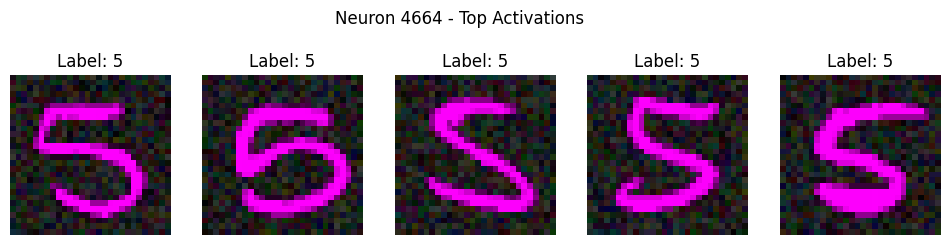

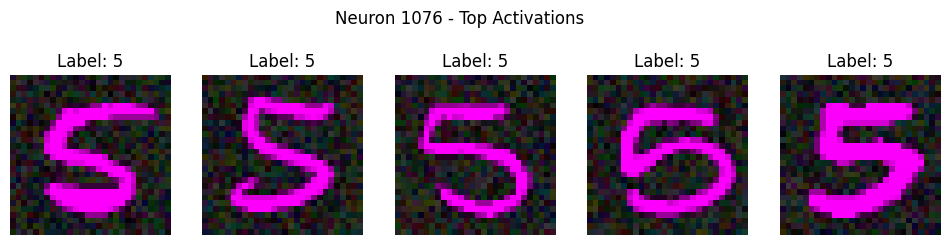

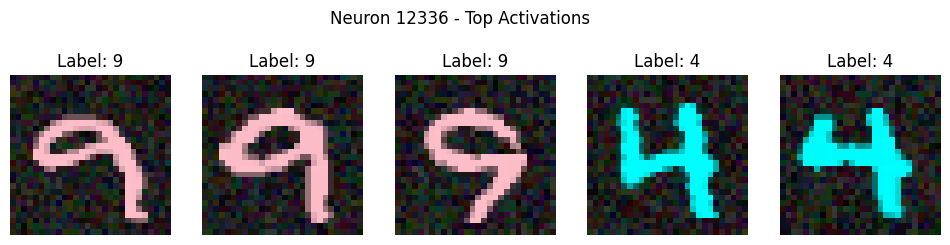

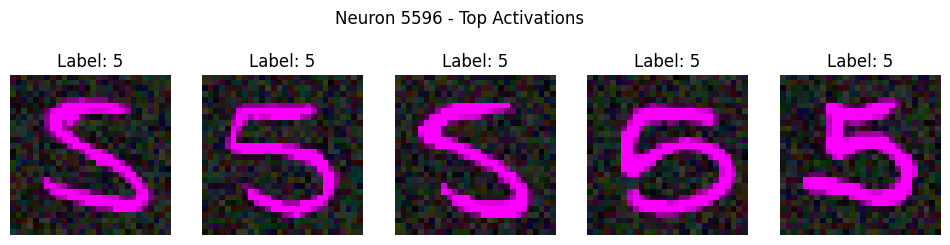

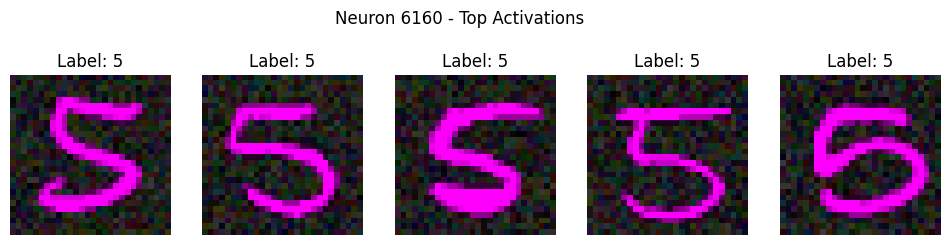

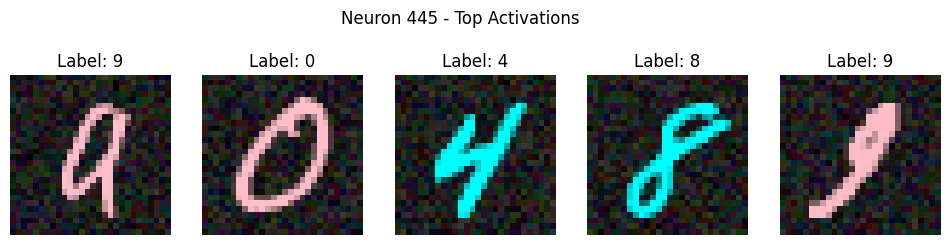

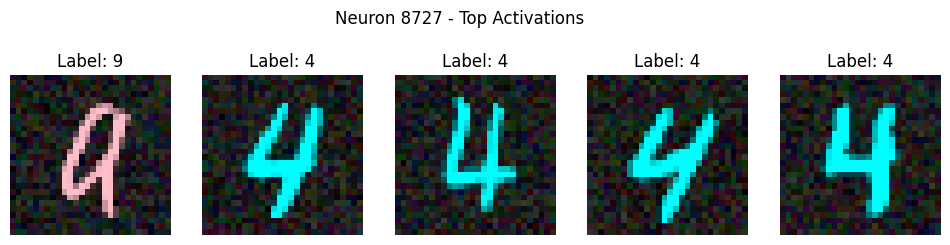

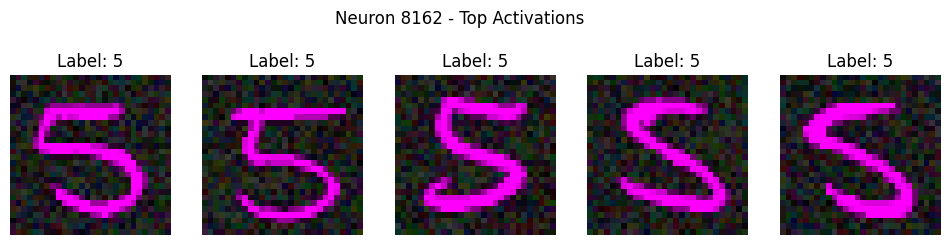

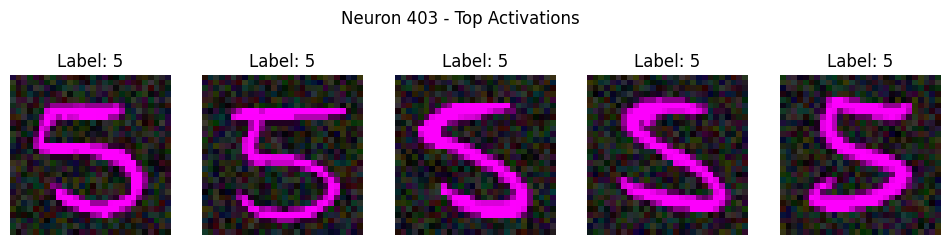

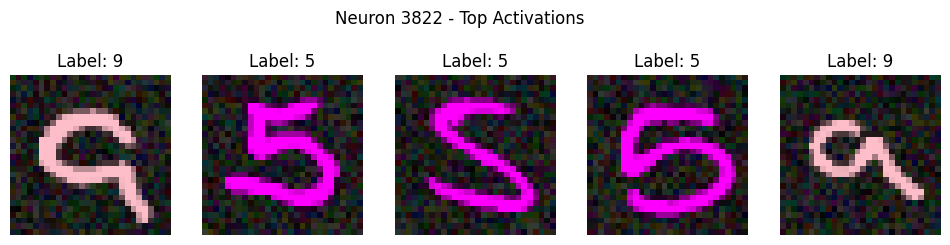

In [ ]:
for neuron in top_neurons[:10]:
    visualize_top_activations(neuron.item())

# **Intervention**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 5 epoch model
model5 = SimpleCNN().to(device)
model5.load_state_dict(torch.load("model_5epoch.pth", map_location=device))
model5.eval()

# 10 epoch model
model10 = SimpleCNN().to(device)
model10.load_state_dict(torch.load("model_10epoch.pth", map_location=device))
model10.eval()

# Freeze both
for param in model5.parameters():
    param.requires_grad = False

for param in model10.parameters():
    param.requires_grad = False

print("Models loaded and frozen.")

Models loaded and frozen.


In [ ]:
def get_last_conv_activation(model, image):
    activations = []

    def hook_fn(module, input, output):
        activations.append(output)

    handle = model.features[6].register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(image)

    handle.remove()
    return activations[0]

In [ ]:
def forward_from_activation(model, activation):
    x = activation

    x = model.features[7](x)   # ReLU
    x = model.features[8](x)   # AdaptiveAvgPool2d(1)

    x = x.view(x.size(0), -1)

    x = model.classifier(x)

    return x

In [ ]:
def intervene_model(model, sae, image, target_neuron, scale=0.0):
    model.eval()
    sae.eval()

    # 1. Get last conv activation
    act = get_last_conv_activation(model, image)

    # 2. Flatten
    flat = act.view(1, -1)

    # 3. Encode through SAE
    with torch.no_grad():
        _, hidden = sae(flat)

    # 4. Modify chosen neuron
    hidden_modified = hidden.clone()
    hidden_modified[0, target_neuron] *= scale  # 0 = remove, 2 = boost

    # 5. Decode back
    with torch.no_grad():
        recon = sae.decoder(hidden_modified)

    # 6. Reshape back to conv format
    recon = recon.view_as(act)

    # 7. Forward through classifier only
    with torch.no_grad():
        output = forward_from_activation(model, recon)

    pred = output.argmax(dim=1).item()
    return pred

In [ ]:
test_idx = None

for idx in range(len(train_dataset)):
    label = train_dataset.mnist.targets[idx].item()
    color = train_dataset.color_assignments[idx]
    if label == 5 and color == 5:
        test_idx = idx
        break

if test_idx is None:
    print("No biased pink 5 found in train set.")
else:
    img, label = train_dataset[test_idx]
    img = img.unsqueeze(0).to(device)
    print("True label:", label)

True label: 5


In [ ]:
target_neuron_5 = 6119

# Original
with torch.no_grad():
    original_pred5 = model5(img).argmax(dim=1).item()

# Dial down
pred_down5 = intervene_model(model5, sae, img, target_neuron_5, scale=0.0)

print("5 Epoch Model")
print("Original prediction:", original_pred5)
print("After dial-down:", pred_down5)

5 Epoch Model
Original prediction: 5
After dial-down: 2


In [ ]:
target_neuron_10 = 4664

# Original
with torch.no_grad():
    original_pred10 = model10(img).argmax(dim=1).item()

# Dial down
pred_down10 = intervene_model(model10, sae, img, target_neuron_10, scale=0.0)

print("10 Epoch Model")
print("Original prediction:", original_pred10)
print("After dial-down:", pred_down10)


10 Epoch Model
Original prediction: 5
After dial-down: 9
